In [1]:
# rastermap
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
# importing rastermap
# (this will be slow the first time since it is compiling the numba functions)
from rastermap import Rastermap, utils
from scipy.stats import zscore

In [2]:
matrix_file = r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\frame_by_good_cluster_matrix.npy"
behave_file = r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\full_video_dataframe.csv"

In [3]:
frame_by_cluster_matrix = np.load(matrix_file)
video_df = pl.read_csv(behave_file)

In [21]:
behave = video_df['hdir'].to_numpy()
shelt = video_df['OutofshelterIdx']

In [4]:
spks = zscore(frame_by_cluster_matrix.T, axis=1) # need neurons x time
spks = spks[:200]

In [17]:
model = Rastermap(n_clusters=None, # None turns off clustering and sorts single neurons 
                  n_PCs=64, # use fewer PCs than neurons
                  locality=0.15, # some locality in sorting (this is a value from 0-1)
                  time_lag_window=15, # use future timepoints to compute correlation
                  grid_upsample=0, # 0 turns off upsampling since we're using single neurons
                ).fit(spks[:200])
y = model.embedding # neurons x 1
isort = model.isort

normalizing data across axis=1
projecting out mean along axis=0
data normalized, 6.95sec
sorting activity: 200 valid samples by 665486 timepoints
n_PCs = 64 computed, 26.74sec
skipping clustering, n_clusters is None
clusters sorted, time 326.63sec
rastermap complete, time 327.20sec


Text(0, 0.5, 'neurons')

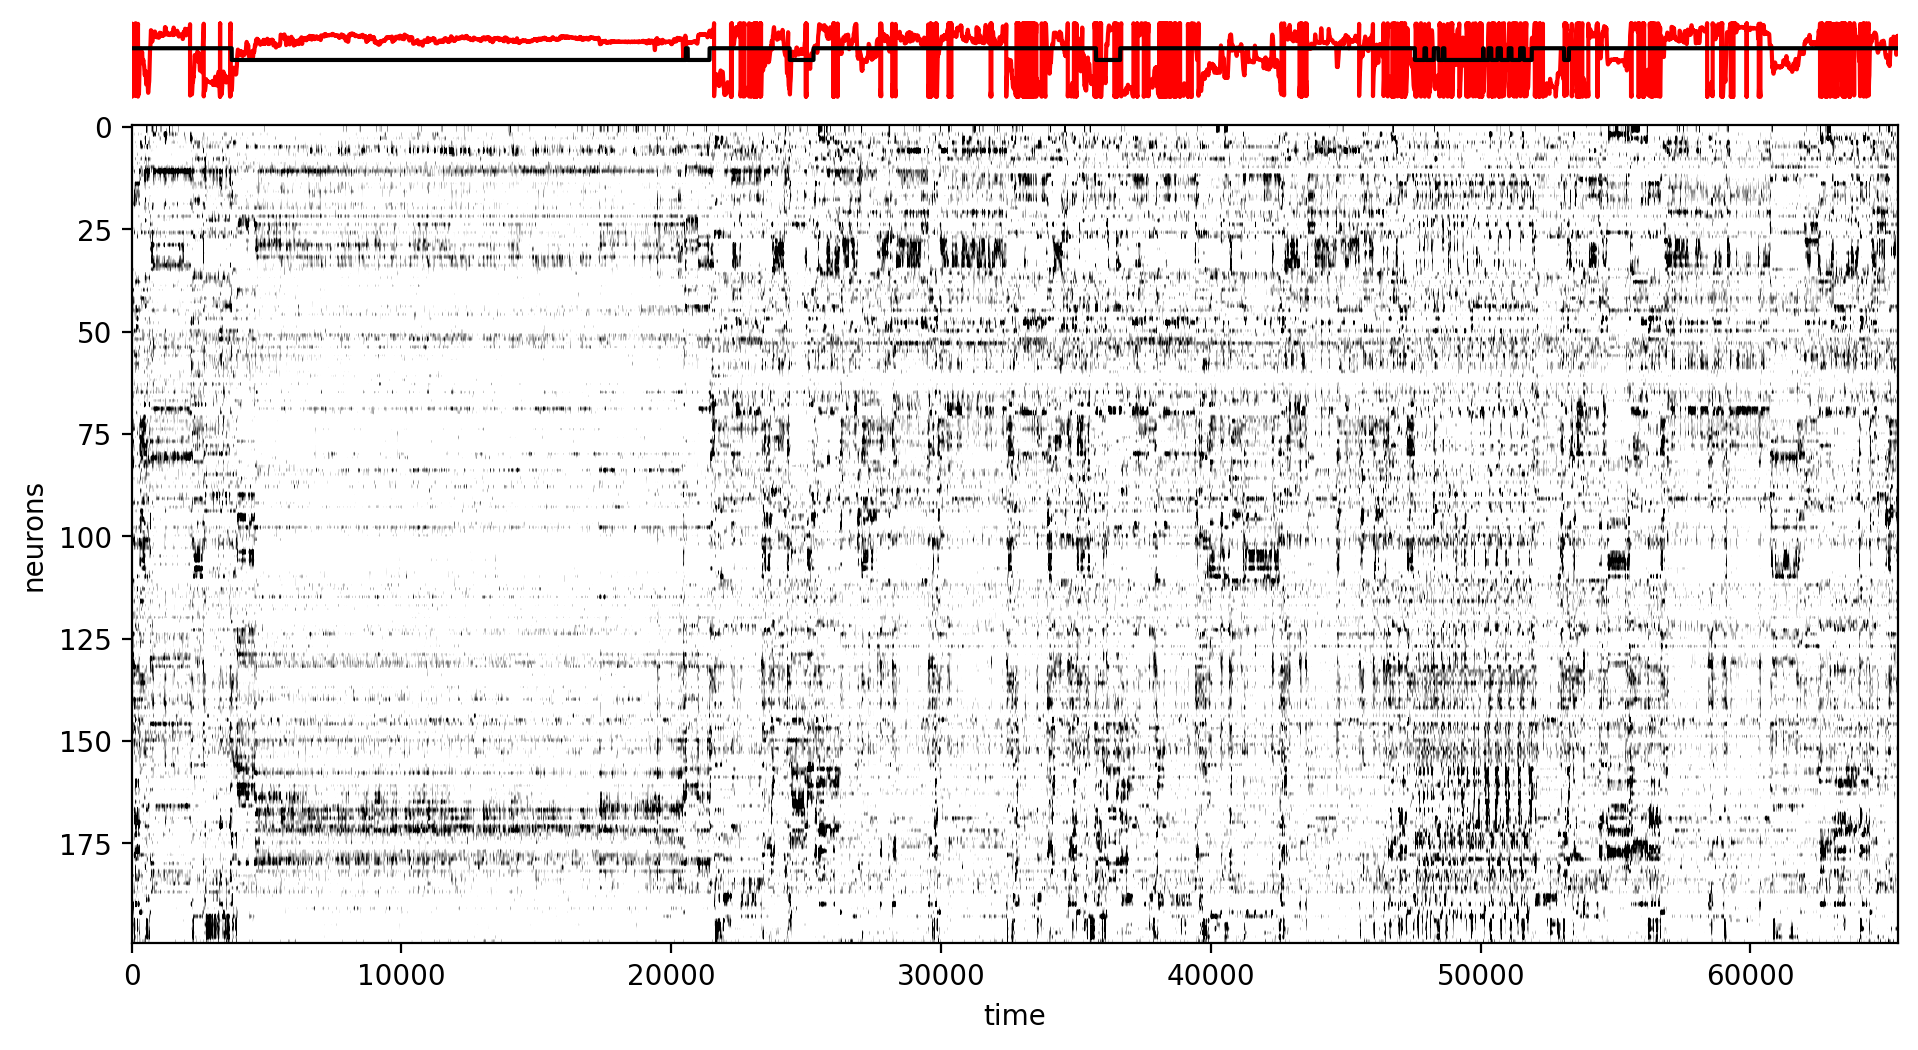

In [18]:
# timepoints to visualize
xmin = 600000 
xmax = -1

# make figure with grid for easy plotting
fig = plt.figure(figsize=(12,6), dpi=200)
grid = plt.GridSpec(9, 20, figure=fig, wspace = 0.05, hspace = 0.3)

# plot running speed
ax = plt.subplot(grid[0, :-1])
ax.plot(behave[xmin:xmax], color='r')
ax.plot(shelt[xmin:xmax], color='k')
ax.set_xlim((0,len(shelt[xmin:xmax])))
ax.axis("off")

# plot superneuron activity
ax = plt.subplot(grid[1:, :-1])
ax.imshow(spks[isort,xmin:xmax], cmap="gray_r", vmin=0, vmax=1.2, aspect="auto")
ax.set_xlabel("time")
ax.set_ylabel("neurons")


In [33]:
np.shape(spks)

(200, 665486)

Text(0, 0.5, 'neurons')

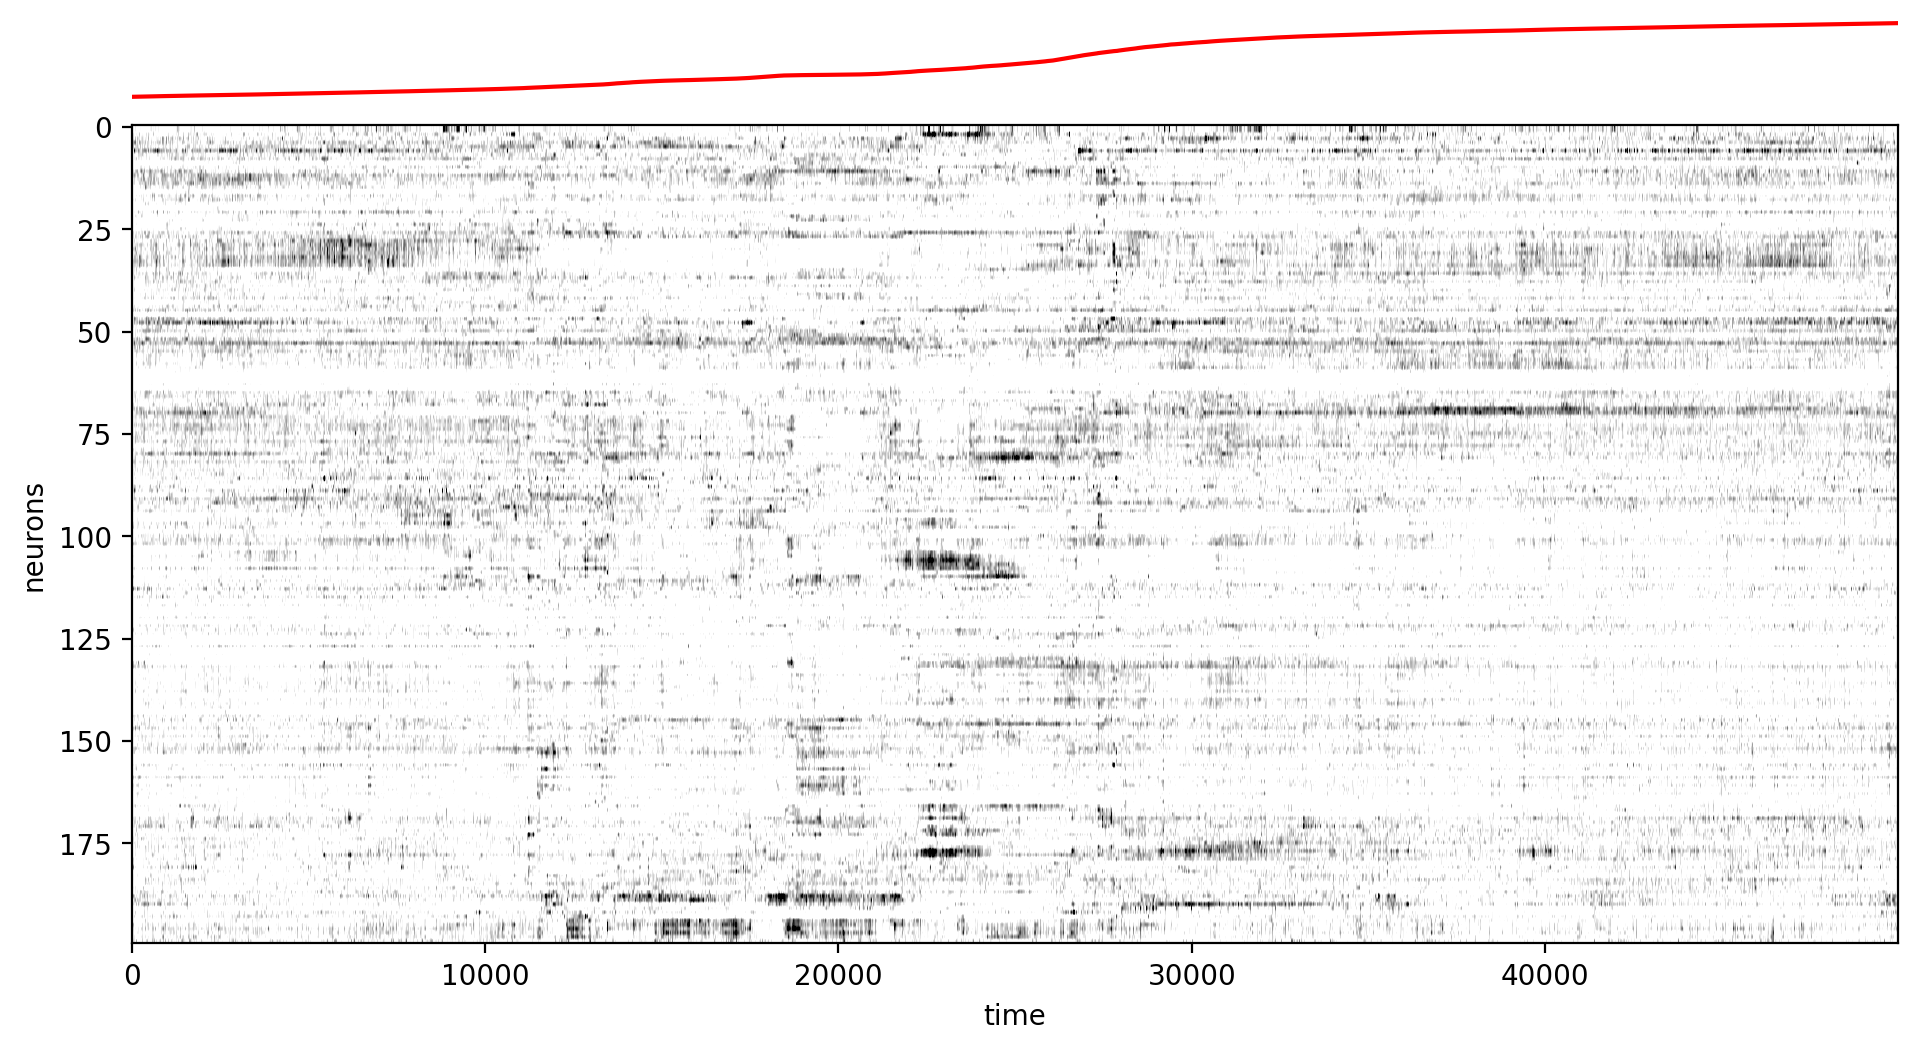

In [35]:
behave = video_df['hsa'].to_numpy()
out = spks[:,shelt]
out = out[isort,:]
out_b = behave[shelt]
# timepoints to visualize
xmin = -50000 
xmax = -1
out = out[:,xmin:xmax]
out_b = behave[xmin:xmax]
h_sort = np.argsort(out_b)

# make figure with grid for easy plotting
fig = plt.figure(figsize=(12,6), dpi=200)
grid = plt.GridSpec(9, 20, figure=fig, wspace = 0.05, hspace = 0.3)

# plot running speed
ax = plt.subplot(grid[0, :-1])
ax.plot(out_b[h_sort], color='r')
# ax.plot(shelt[xmin:xmax], color='k')
ax.set_xlim((0,len(out_b)))
ax.axis("off")

# plot superneuron activity
ax = plt.subplot(grid[1:, :-1])
ax.imshow(out[:,h_sort], cmap="gray_r", vmin=0, vmax=1.2, aspect="auto")
ax.set_xlabel("time")
ax.set_ylabel("neurons")